IMPORT DATA

In [9]:
!pip -q install pandas numpy scikit-learn matplotlib joblib

In [10]:
import os
import json
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import silhouette_score, mean_absolute_error, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

ZIP_PATH = '/content/Smart_Expense_Data_Science.zip'
EXTRACT_DIR = Path('/content/smart_expense_data')
ARTIFACT_DIR = Path('/content/smart_expense_ai_artifacts')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print('Siap. Pastikan ZIP_PATH benar:', ZIP_PATH)

Siap. Pastikan ZIP_PATH benar: /content/Smart_Expense_Data_Science.zip


LOAD DATA

In [17]:
if not Path(ZIP_PATH).exists():
    candidates = list(Path('/content').glob('*.zip'))
    print('File ZIP belum ditemukan di ZIP_PATH. Kandidat ZIP di /content:', candidates)
    raise FileNotFoundError('Upload Smart_Expense_Data_Science.zip ke Colab atau ubah ZIP_PATH.')

if not EXTRACT_DIR.exists():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

roots = [p for p in EXTRACT_DIR.iterdir() if p.is_dir()]
BASE_DIR = roots[0] if roots else EXTRACT_DIR
print('BASE_DIR:', BASE_DIR)
print('Isi folder:')
for p in sorted(BASE_DIR.rglob('*')):
    if p.is_file():
        print('-', p.relative_to(BASE_DIR))

BASE_DIR: /content/smart_expense_data/Smart_Expense_Data_Science
Isi folder:
- Personal_Finance_Dataset.csv
- Tabel 3.1 Rata-Rata Pengeluaran per Kapita Sebulan Menurut Kelompok Komoditas dan Klasifikasi Desa (rupiah), Maret 2025.csv
- Tabel 3.2 Persentase Pengeluaran per Kapita Sebulan Menurut Kelompok Komoditas dan Klasifikasi Desa, Maret 2025.csv
- app.py
- data/ab_testing_simulation.csv
- data/bps_commodity_clean.csv
- data/monthly_features.csv
- data/personal_finance_clean.csv
- data/personal_finance_features.csv
- outputs/figures/bps_top_commodity.html
- outputs/figures/expense_by_bucket.html
- outputs/figures/monthly_trend.html
- outputs/figures/top_categories.html
- outputs/laporan_teknis_smart_expense.pdf
- outputs/tables/ab_testing_result.csv
- outputs/tables/data_dictionary.csv
- outputs/tables/finance_summary.csv
- requirements.txt


In [18]:
# Load dataset utama
finance_raw = pd.read_csv(BASE_DIR / 'Personal_Finance_Dataset.csv')
finance_clean = pd.read_csv(BASE_DIR / 'data' / 'personal_finance_clean.csv')
finance_features = pd.read_csv(BASE_DIR / 'data' / 'personal_finance_features.csv')
monthly = pd.read_csv(BASE_DIR / 'data' / 'monthly_features.csv')
bps = pd.read_csv(BASE_DIR / 'data' / 'bps_commodity_clean.csv')
ab_test = pd.read_csv(BASE_DIR / 'data' / 'ab_testing_simulation.csv')

print('finance_raw:', finance_raw.shape)
print('finance_clean:', finance_clean.shape)
print('finance_features:', finance_features.shape)
print('monthly:', monthly.shape)
print('bps:', bps.shape)
print('ab_test:', ab_test.shape)

display(finance_clean.head())
display(monthly.head())

finance_raw: (1500, 5)
finance_clean: (1500, 9)
finance_features: (1500, 14)
monthly: (60, 10)
bps: (30, 7)
ab_test: (160, 3)


,date,description,category,amount,type,type_clean,month,year,bucket
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense,expense,2020-01,2020,kebutuhan_pokok
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense,expense,2020-01,2020,kebutuhan_pokok
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense,expense,2020-01,2020,kebutuhan_pokok
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income,income,2020-01,2020,tabungan
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense,expense,2020-01,2020,kebutuhan_pokok


,month,income,kebutuhan_pokok,kebutuhan_sekunder,lainnya,tabungan,total_allocated,saving_rate,needs_rate,wants_rate
0,2020-01,1077.09,10597.31,3093.51,5657.34,2291.0,15981.82,0.143350,0.663085,0.193564
1,2020-02,294.31,4075.70,11971.59,13642.81,7194.0,23241.29,0.309535,0.175365,0.515100
2,2020-03,0.00,8397.35,4302.64,1961.82,2385.0,15084.99,0.158104,0.556669,0.285227
3,2020-04,2222.60,5001.47,7405.80,5005.18,3968.0,16375.27,0.242317,0.305428,0.452255
4,2020-05,318.05,8027.68,5606.42,2893.98,6008.0,19642.10,0.305874,0.408698,0.285429


DATA QUALITY CHECK

In [19]:
def data_quality_report(df, name):
    return pd.DataFrame({
        'dataset': name,
        'column': df.columns,
        'dtype': [str(df[c].dtype) for c in df.columns],
        'missing_count': [df[c].isna().sum() for c in df.columns],
        'missing_pct': [round(df[c].isna().mean()*100, 2) for c in df.columns],
        'unique_count': [df[c].nunique(dropna=True) for c in df.columns]
    })

quality = pd.concat([
    data_quality_report(finance_clean, 'finance_clean'),
    data_quality_report(monthly, 'monthly_features'),
    data_quality_report(bps, 'bps_commodity_clean')
], ignore_index=True)

display(quality)

,dataset,column,dtype,missing_count,missing_pct,unique_count
0,finance_clean,date,object,0,0.00,1025
1,finance_clean,description,object,0,0.00,1500
2,finance_clean,category,object,0,0.00,10
3,finance_clean,amount,float64,0,0.00,1492
4,finance_clean,type,object,0,0.00,2
5,finance_clean,type_clean,object,0,0.00,2
6,finance_clean,month,object,0,0.00,60
7,finance_clean,year,int64,0,0.00,5
8,finance_clean,bucket,object,0,0.00,5
9,monthly_features,month,object,0,0.00,60


EXPLORATORY DATA

In [20]:
summary = finance_clean.groupby('type_clean')['amount'].sum().sort_values(ascending=False)
display(summary.to_frame('total_amount'))

bucket_summary = finance_clean.groupby('bucket')['amount'].sum().sort_values(ascending=False)
display(bucket_summary.to_frame('total_amount'))

category_summary = finance_clean.groupby('category')['amount'].sum().sort_values(ascending=False).head(10)
display(category_summary.to_frame('total_amount'))

,total_amount
type_clean,
expense,1227194.37
income,734087.00


,total_amount
bucket,
lainnya,516029.06
kebutuhan_pokok,468402.75
kebutuhan_sekunder,464544.01
tabungan,363252.00
income,149053.55


,total_amount
category,
Other,370835.00
Investment,363252.00
Travel,169497.79
Rent,162075.39
Food & Drink,159493.39
Salary,149053.55
Entertainment,148165.47
Shopping,146880.75
Utilities,146833.97


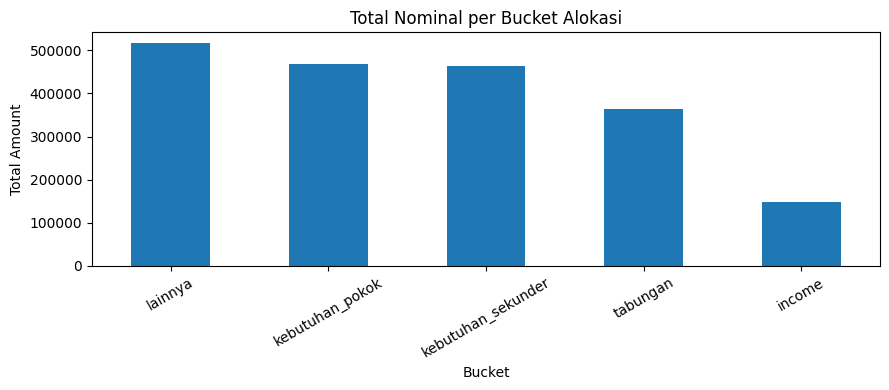

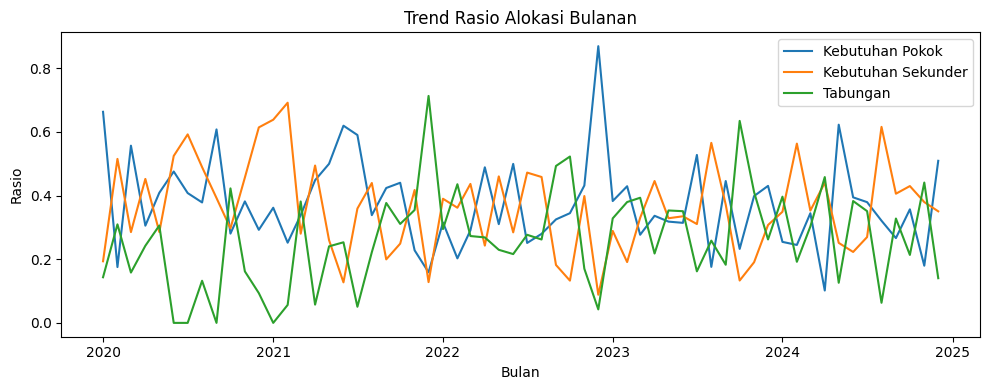

In [21]:
plt.figure(figsize=(9, 4))
bucket_summary.plot(kind='bar')
plt.title('Total Nominal per Bucket Alokasi')
plt.xlabel('Bucket')
plt.ylabel('Total Amount')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
monthly_plot = monthly.copy()
monthly_plot['month'] = pd.to_datetime(monthly_plot['month'])
plt.plot(monthly_plot['month'], monthly_plot['needs_rate'], label='Kebutuhan Pokok')
plt.plot(monthly_plot['month'], monthly_plot['wants_rate'], label='Kebutuhan Sekunder')
plt.plot(monthly_plot['month'], monthly_plot['saving_rate'], label='Tabungan')
plt.title('Trend Rasio Alokasi Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Rasio')
plt.legend()
plt.tight_layout()
plt.show()

AI RECOMENDATION ENGINE

In [22]:
class SmartExpenseRuleEngine:
    """
    Rule-based recommendation engine untuk alokasi keuangan personal.

    Kategori utama:
    - kebutuhan_pokok
    - kebutuhan_sekunder
    - tabungan
    - dana_darurat

    Prinsip dasar memakai variasi 50/30/20, lalu disesuaikan dengan nominal dan profil risiko.
    """

    def __init__(self):
        self.profiles = {
            'hemat': {
                'kebutuhan_pokok': 0.55,
                'kebutuhan_sekunder': 0.20,
                'tabungan': 0.20,
                'dana_darurat': 0.05,
            },
            'seimbang': {
                'kebutuhan_pokok': 0.50,
                'kebutuhan_sekunder': 0.30,
                'tabungan': 0.15,
                'dana_darurat': 0.05,
            },
            'agresif_menabung': {
                'kebutuhan_pokok': 0.45,
                'kebutuhan_sekunder': 0.20,
                'tabungan': 0.30,
                'dana_darurat': 0.05,
            }
        }

    def detect_income_tier(self, amount):
        if amount < 1_500_000:
            return 'rendah'
        if amount < 5_000_000:
            return 'menengah'
        return 'tinggi'

    def adjust_profile_by_income(self, base_profile, amount):
        profile = self.profiles[base_profile].copy()
        tier = self.detect_income_tier(amount)

        # Untuk nominal rendah, kebutuhan pokok biasanya lebih dominan.
        if tier == 'rendah':
            profile['kebutuhan_pokok'] += 0.10
            profile['kebutuhan_sekunder'] -= 0.07
            profile['tabungan'] -= 0.03

        # Untuk nominal tinggi, dorong tabungan/investasi lebih besar.
        elif tier == 'tinggi':
            profile['kebutuhan_pokok'] -= 0.05
            profile['tabungan'] += 0.05

        # Normalisasi agar total selalu 100%.
        total = sum(profile.values())
        profile = {k: v / total for k, v in profile.items()}
        return profile

    def recommend(self, amount, profile='seimbang', custom_percentages=None):
        if amount <= 0:
            raise ValueError('Nominal uang harus lebih besar dari 0.')

        if custom_percentages is not None:
            ratio = custom_percentages.copy()
            total = sum(ratio.values())
            if not np.isclose(total, 1.0):
                ratio = {k: v / total for k, v in ratio.items()}
        else:
            if profile not in self.profiles:
                profile = 'seimbang'
            ratio = self.adjust_profile_by_income(profile, amount)

        allocation = {k: round(amount * v, 2) for k, v in ratio.items()}
        result = {
            'input_amount': amount,
            'income_tier': self.detect_income_tier(amount),
            'profile': profile,
            'percentages': {k: round(v * 100, 2) for k, v in ratio.items()},
            'allocation': allocation,
            'total_allocated': round(sum(allocation.values()), 2),
            'suggestions': self.generate_suggestions(amount, ratio, allocation)
        }
        return result

    def generate_suggestions(self, amount, ratio, allocation):
        suggestions = []
        saving_total = ratio.get('tabungan', 0) + ratio.get('dana_darurat', 0)
        wants = ratio.get('kebutuhan_sekunder', 0)
        needs = ratio.get('kebutuhan_pokok', 0)

        if saving_total < 0.20:
            suggestions.append('Porsi tabungan dan dana darurat masih di bawah 20%. Coba kurangi kebutuhan sekunder secara bertahap.')
        else:
            suggestions.append('Porsi tabungan sudah cukup sehat. Pertahankan konsistensi setiap periode gajian.')

        if wants > 0.30:
            suggestions.append('Kebutuhan sekunder cukup besar. Prioritaskan pengeluaran penting sebelum hiburan atau belanja tambahan.')

        if needs > 0.60:
            suggestions.append('Kebutuhan pokok mendominasi alokasi. Pastikan nominal kebutuhan pokok benar-benar wajib dan cari opsi penghematan rutin.')

        if amount < 1_500_000:
            suggestions.append('Karena nominal termasuk rendah, fokus utama adalah kebutuhan pokok dan membangun tabungan kecil secara konsisten.')
        elif amount >= 5_000_000:
            suggestions.append('Karena nominal relatif tinggi, pertimbangkan menaikkan porsi tabungan, dana darurat, atau investasi rendah risiko.')

        suggestions.append(f"Simpan minimal Rp{allocation.get('tabungan', 0):,.0f} sebagai tabungan utama pada periode ini.")
        return suggestions

engine = SmartExpenseRuleEngine()
engine.recommend(3_000_000, profile='seimbang')

{'input_amount': 3000000,
 'income_tier': 'menengah',
 'profile': 'seimbang',
 'percentages': {'kebutuhan_pokok': 50.0,
  'kebutuhan_sekunder': 30.0,
  'tabungan': 15.0,
  'dana_darurat': 5.0},
 'allocation': {'kebutuhan_pokok': 1500000.0,
  'kebutuhan_sekunder': 900000.0,
  'tabungan': 450000.0,
  'dana_darurat': 150000.0},
 'total_allocated': 3000000.0,
 'suggestions': ['Porsi tabungan sudah cukup sehat. Pertahankan konsistensi setiap periode gajian.',
  'Simpan minimal Rp450,000 sebagai tabungan utama pada periode ini.']}

MODEL SEGMENTASI PROFIL FINANSIAL

In [23]:
model_df = monthly.copy()
feature_cols = ['income', 'needs_rate', 'wants_rate', 'saving_rate']
model_df = model_df.dropna(subset=feature_cols).copy()

# Batasi rasio ekstrem agar model stabil
for col in ['needs_rate', 'wants_rate', 'saving_rate']:
    model_df[col] = model_df[col].clip(0, 1)

X = model_df[feature_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Pilih K=3 agar mudah dipetakan ke persona aplikasi
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_scaled)
model_df['cluster'] = clusters

sil = silhouette_score(X_scaled, clusters) if len(set(clusters)) > 1 else np.nan
print('Silhouette score:', round(sil, 3))

display(model_df.groupby('cluster')[feature_cols].mean())

Silhouette score: 0.256


,income,needs_rate,wants_rate,saving_rate
cluster,,,,
0,2195.425385,0.576873,0.270536,0.152591
1,2823.291852,0.313324,0.292009,0.394667
2,2214.207000,0.326226,0.515840,0.157934


In [24]:
def name_cluster(row):
    if row['saving_rate'] >= row['saving_rate_mean_all'] and row['wants_rate'] <= row['wants_rate_mean_all']:
        return 'agresif_menabung'
    if row['wants_rate'] >= row['wants_rate_mean_all']:
        return 'konsumtif_sekunder'
    return 'fokus_kebutuhan_pokok'

cluster_summary = model_df.groupby('cluster')[feature_cols].mean().reset_index()
cluster_summary['saving_rate_mean_all'] = model_df['saving_rate'].mean()
cluster_summary['wants_rate_mean_all'] = model_df['wants_rate'].mean()
cluster_summary['persona'] = cluster_summary.apply(name_cluster, axis=1)
cluster_to_persona = dict(zip(cluster_summary['cluster'], cluster_summary['persona']))
model_df['persona'] = model_df['cluster'].map(cluster_to_persona)

display(cluster_summary[['cluster', 'persona'] + feature_cols])

,cluster,persona,income,needs_rate,wants_rate,saving_rate
0,0,fokus_kebutuhan_pokok,2195.425385,0.576873,0.270536,0.152591
1,1,agresif_menabung,2823.291852,0.313324,0.292009,0.394667
2,2,konsumtif_sekunder,2214.207000,0.326226,0.515840,0.157934


PERSONA CLASSIFIER

In [25]:
X = model_df[feature_cols]
y = model_df['persona']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y if y.nunique() > 1 else None
)

persona_model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'))
])
persona_model.fit(X_train, y_train)

y_pred = persona_model.predict(X_test)
print(classification_report(y_test, y_pred))

                       precision    recall  f1-score   support

     agresif_menabung       1.00      1.00      1.00         7
fokus_kebutuhan_pokok       1.00      1.00      1.00         3
   konsumtif_sekunder       1.00      1.00      1.00         5

             accuracy                           1.00        15
            macro avg       1.00      1.00      1.00        15
         weighted avg       1.00      1.00      1.00        15



MODEL REGRESI

In [26]:
regression_features = ['income']
target_cols = ['needs_rate', 'wants_rate', 'saving_rate']

regressors = {}
regression_metrics = []

for target in target_cols:
    X = model_df[regression_features]
    y = model_df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

    reg = RandomForestRegressor(n_estimators=300, random_state=42, min_samples_leaf=2)
    reg.fit(X_train, y_train)
    pred = np.clip(reg.predict(X_test), 0, 1)
    mae = mean_absolute_error(y_test, pred)

    regressors[target] = reg
    regression_metrics.append({'target': target, 'MAE': mae})

metrics_df = pd.DataFrame(regression_metrics)
display(metrics_df)

,target,MAE
0,needs_rate,0.111951
1,wants_rate,0.167582
2,saving_rate,0.129155


In [27]:
def ml_ratio_recommendation(amount):
    raw = {
        'kebutuhan_pokok': float(regressors['needs_rate'].predict(pd.DataFrame({'income': [amount]}))[0]),
        'kebutuhan_sekunder': float(regressors['wants_rate'].predict(pd.DataFrame({'income': [amount]}))[0]),
        'tabungan': float(regressors['saving_rate'].predict(pd.DataFrame({'income': [amount]}))[0]),
    }
    # Tambahkan dana darurat minimal 5%, lalu normalisasi.
    raw = {k: max(v, 0.01) for k, v in raw.items()}
    raw['dana_darurat'] = 0.05
    total = sum(raw.values())
    return {k: v / total for k, v in raw.items()}

ml_ratio_recommendation(3_000_000)

{'kebutuhan_pokok': 0.3890026803946167,
 'kebutuhan_sekunder': 0.36363614999988425,
 'tabungan': 0.20037326710605505,
 'dana_darurat': 0.046987902499443956}

HYBRID RECOMMENDATION FUNCTION

In [28]:
def recommend_smart_expense(amount, profile='seimbang', use_ml_blending=False):
    base = engine.recommend(amount, profile=profile)

    # Feature sederhana untuk prediksi persona.
    p = base['percentages']
    persona_input = pd.DataFrame({
        'income': [amount],
        'needs_rate': [p['kebutuhan_pokok'] / 100],
        'wants_rate': [p['kebutuhan_sekunder'] / 100],
        'saving_rate': [(p['tabungan'] + p['dana_darurat']) / 100],
    })
    persona = persona_model.predict(persona_input)[0]

    ml_ratio = ml_ratio_recommendation(amount)

    if use_ml_blending:
        # Blend konservatif: 70% rule-based, 30% ML.
        rule_ratio = {k: v / 100 for k, v in base['percentages'].items()}
        blended = {k: 0.7 * rule_ratio[k] + 0.3 * ml_ratio[k] for k in rule_ratio}
        total = sum(blended.values())
        blended = {k: v / total for k, v in blended.items()}
        base = engine.recommend(amount, profile=profile, custom_percentages=blended)

    base['predicted_persona'] = persona
    base['ml_ratio_reference'] = {k: round(v * 100, 2) for k, v in ml_ratio.items()}
    base['integration_payload'] = {
        'amount': amount,
        'incomeTier': base['income_tier'],
        'profile': base['profile'],
        'persona': persona,
        'allocation': base['allocation'],
        'percentages': base['percentages'],
        'suggestions': base['suggestions']
    }
    return base

sample_result = recommend_smart_expense(3_000_000, profile='seimbang')
json.dumps(sample_result['integration_payload'], indent=2, ensure_ascii=False)

'{\n  "amount": 3000000,\n  "incomeTier": "menengah",\n  "profile": "seimbang",\n  "persona": "fokus_kebutuhan_pokok",\n  "allocation": {\n    "kebutuhan_pokok": 1500000.0,\n    "kebutuhan_sekunder": 900000.0,\n    "tabungan": 450000.0,\n    "dana_darurat": 150000.0\n  },\n  "percentages": {\n    "kebutuhan_pokok": 50.0,\n    "kebutuhan_sekunder": 30.0,\n    "tabungan": 15.0,\n    "dana_darurat": 5.0\n  },\n  "suggestions": [\n    "Porsi tabungan sudah cukup sehat. Pertahankan konsistensi setiap periode gajian.",\n    "Simpan minimal Rp450,000 sebagai tabungan utama pada periode ini."\n  ]\n}'

In [29]:
scenarios = [750_000, 1_500_000, 3_000_000, 5_000_000, 10_000_000]
rows = []
for amount in scenarios:
    rec = recommend_smart_expense(amount, profile='seimbang')
    row = {'amount': amount, 'income_tier': rec['income_tier'], 'persona': rec['predicted_persona']}
    row.update(rec['allocation'])
    rows.append(row)

scenario_df = pd.DataFrame(rows)
display(scenario_df)

,amount,income_tier,persona,kebutuhan_pokok,kebutuhan_sekunder,tabungan,dana_darurat
0,750000,rendah,fokus_kebutuhan_pokok,450000.0,172500.0,90000.0,37500.0
1,1500000,menengah,fokus_kebutuhan_pokok,750000.0,450000.0,225000.0,75000.0
2,3000000,menengah,fokus_kebutuhan_pokok,1500000.0,900000.0,450000.0,150000.0
3,5000000,tinggi,fokus_kebutuhan_pokok,2250000.0,1500000.0,1000000.0,250000.0
4,10000000,tinggi,fokus_kebutuhan_pokok,4500000.0,3000000.0,2000000.0,500000.0


In [ ]:
plot_df = scenario_df.set_index('amount')[['kebutuhan_pokok', 'kebutuhan_sekunder', 'tabungan', 'dana_darurat']]
plot_df.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Simulasi Rekomendasi Alokasi Berdasarkan Nominal')
plt.xlabel('Nominal Input')
plt.ylabel('Alokasi Rupiah')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

MODEL TENSORFLOW

In [30]:
!pip -q install tensorflow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


In [31]:
# Cek nama kolom dulu
print(monthly.columns.tolist())

dl_df = monthly.copy()

# Buat kolom needs/wants/savings jika belum ada
if 'needs' not in dl_df.columns:
    if 'needs_amount' in dl_df.columns:
        dl_df['needs'] = dl_df['needs_amount']
    elif 'Needs' in dl_df.columns:
        dl_df['needs'] = dl_df['Needs']
    else:
        dl_df['needs'] = dl_df['income'] * 0.50

if 'wants' not in dl_df.columns:
    if 'wants_amount' in dl_df.columns:
        dl_df['wants'] = dl_df['wants_amount']
    elif 'Wants' in dl_df.columns:
        dl_df['wants'] = dl_df['Wants']
    else:
        dl_df['wants'] = dl_df['income'] * 0.30

if 'savings' not in dl_df.columns:
    if 'savings_amount' in dl_df.columns:
        dl_df['savings'] = dl_df['savings_amount']
    elif 'Savings' in dl_df.columns:
        dl_df['savings'] = dl_df['Savings']
    else:
        dl_df['savings'] = dl_df['income'] * 0.20

# Buat rasio target
dl_df['needs_rate'] = dl_df['needs'] / dl_df['income']
dl_df['wants_rate'] = dl_df['wants'] / dl_df['income']
dl_df['saving_rate'] = dl_df['savings'] / dl_df['income']

# Buang data kosong
dl_df = dl_df.dropna(subset=['income', 'needs_rate', 'wants_rate', 'saving_rate'])

# Feature engineering
dl_df['expense_total'] = dl_df['needs'] + dl_df['wants']
dl_df['cashflow'] = dl_df['income'] - dl_df['expense_total']
dl_df['expense_rate'] = np.where(
    dl_df['income'] > 0,
    dl_df['expense_total'] / dl_df['income'],
    0
)

dl_feature_cols = ['income', 'expense_total', 'cashflow', 'expense_rate']
dl_target_cols = ['needs_rate', 'wants_rate', 'saving_rate']

X_dl = dl_df[dl_feature_cols].astype('float32').values
y_dl = dl_df[dl_target_cols].astype('float32').values

y_dl = y_dl / np.clip(y_dl.sum(axis=1, keepdims=True), 1e-8, None)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_dl, y_dl, test_size=0.2, random_state=42
)

dl_scaler = StandardScaler()
X_train_scaled = dl_scaler.fit_transform(X_train).astype('float32')
X_test_scaled = dl_scaler.transform(X_test).astype('float32')

print('Train shape:', X_train_scaled.shape, y_train.shape)
print('Test shape:', X_test_scaled.shape, y_test.shape)

['month', 'income', 'kebutuhan_pokok', 'kebutuhan_sekunder', 'lainnya', 'tabungan', 'total_allocated', 'saving_rate', 'needs_rate', 'wants_rate']
Train shape: (45, 4) (45, 3)
Test shape: (12, 4) (12, 3)


In [32]:
# Advanced Custom Component 1: Custom Layer
class AllocationSoftmaxLayer(layers.Layer):
    """
    Custom layer untuk memastikan output model berupa rasio alokasi.
    Softmax membuat 3 output bernilai positif dan totalnya = 1.
    """
    def call(self, inputs):
        return tf.nn.softmax(inputs, axis=-1)

# Advanced Custom Component 2: Custom Loss Function
def allocation_balance_loss(y_true, y_pred):
    """
    Loss gabungan:
    - MAE untuk akurasi prediksi rasio.
    - penalty jika total rasio prediksi menyimpang dari 1.
    """
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    sum_penalty = tf.reduce_mean(tf.square(tf.reduce_sum(y_pred, axis=1) - 1.0))
    return mae + 0.2 * sum_penalty

# Advanced Custom Component 3: Custom Callback
class AllocationMonitorCallback(keras.callbacks.Callback):
    """Callback custom untuk memonitor validasi dan sanity check jumlah rasio."""
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        if (epoch + 1) % 10 == 0 or epoch == 0:
            preds = self.model.predict(X_test_scaled[:3], verbose=0)
            avg_sum = preds.sum(axis=1).mean()
            print(f'Epoch {epoch + 1}: val_loss={logs.get("val_loss"):.4f}, avg_prediction_sum={avg_sum:.4f}')

In [33]:
# Build Deep Learning Model menggunakan TensorFlow Functional API
input_layer = keras.Input(shape=(len(dl_feature_cols),), name='financial_features')
x = layers.Dense(32, activation='relu', name='dense_1')(input_layer)
x = layers.Dropout(0.15, name='dropout_1')(x)
x = layers.Dense(16, activation='relu', name='dense_2')(x)
raw_output = layers.Dense(3, name='raw_allocation_logits')(x)
allocation_output = AllocationSoftmaxLayer(name='allocation_ratio_output')(raw_output)

dl_model = keras.Model(inputs=input_layer, outputs=allocation_output, name='smart_expense_allocation_model')

dl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=allocation_balance_loss,
    metrics=[keras.metrics.MeanAbsoluteError(name='mae')]
)

dl_model.summary()

Model: "smart_expense_allocation_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ financial_features (InputLayer) │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ raw_allocation_logits (Dense)   │ (None, 3)              │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ allocation_ratio_output         │ (None, 3)              │             0 │
│ (AllocationSoftmaxLayer)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739 (2.89 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Training model deep learning
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

history = dl_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=8,
    callbacks=[early_stop, AllocationMonitorCallback()],
    verbose=0
)

print('Training selesai. Epoch terbaik:', len(history.history['loss']))
dl_eval = dl_model.evaluate(X_test_scaled, y_test, verbose=0)
print(dict(zip(dl_model.metrics_names, dl_eval)))

Epoch 1: val_loss=0.1262, avg_prediction_sum=1.0000
Epoch 10: val_loss=0.0489, avg_prediction_sum=1.0000
Epoch 20: val_loss=0.0362, avg_prediction_sum=1.0000
Epoch 30: val_loss=0.0187, avg_prediction_sum=1.0000
Epoch 40: val_loss=0.0096, avg_prediction_sum=1.0000
Epoch 50: val_loss=0.0053, avg_prediction_sum=1.0000
Epoch 60: val_loss=0.0035, avg_prediction_sum=1.0000
Epoch 70: val_loss=0.0028, avg_prediction_sum=1.0000
Epoch 80: val_loss=0.0027, avg_prediction_sum=1.0000
Epoch 90: val_loss=0.0017, avg_prediction_sum=1.0000
Epoch 100: val_loss=0.0019, avg_prediction_sum=1.0000
Training selesai. Epoch terbaik: 100
{'loss': 0.0006470042862929404, 'compile_metrics': 0.0006470042862929404}


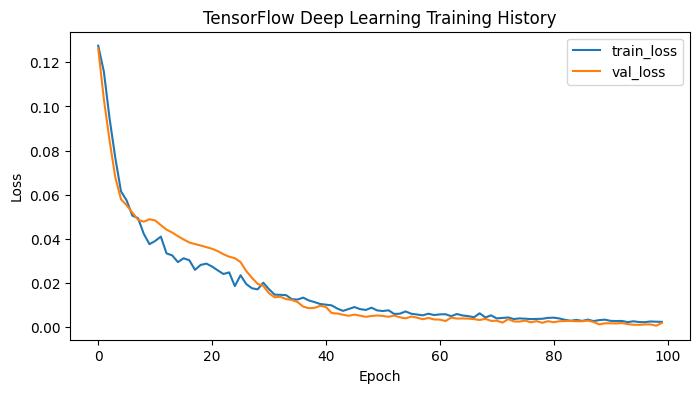

In [35]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('TensorFlow Deep Learning Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [36]:
# Fungsi inference sederhana untuk model TensorFlow
def predict_allocation_tf(income, expense_total=None):
    if expense_total is None:
        # default asumsi pengeluaran 70% dari pemasukan jika user baru belum punya histori
        expense_total = income * 0.70
    cashflow = income - expense_total
    expense_rate = expense_total / income if income > 0 else 0

    features = pd.DataFrame([{
        'income': income,
        'expense_total': expense_total,
        'cashflow': cashflow,
        'expense_rate': expense_rate
    }])[dl_feature_cols].astype('float32')

    features_scaled = dl_scaler.transform(features).astype('float32')
    pred = dl_model.predict(features_scaled, verbose=0)[0]

    result = {
        'kebutuhan_pokok': float(pred[0]),
        'kebutuhan_sekunder': float(pred[1]),
        'tabungan': float(pred[2]),
    }
    return result

predict_allocation_tf(3_500_000)

{'kebutuhan_pokok': 1.0,
 'kebutuhan_sekunder': 1.9301650517575423e-20,
 'tabungan': 1.4731067749771062e-25}

In [45]:
hasil = predict_allocation_tf(5000000)

print(hasil)

{'kebutuhan_pokok': 1.0, 'kebutuhan_sekunder': 8.40820569190635e-29, 'tabungan': 4.513931669271423e-36}


In [46]:
from groq import Groq

client = Groq(
    api_key="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"
)

hasil = predict_allocation_tf(5000000)

prompt = f"""
Berikut hasil prediksi alokasi keuangan user:

Kebutuhan Pokok: {hasil['kebutuhan_pokok']}
Kebutuhan Sekunder: {hasil['kebutuhan_sekunder']}
Tabungan: {hasil['tabungan']}

Berikan analisis kondisi keuangan dan saran yang mudah dipahami.
"""

response = client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ],
    model="llama-3.3-70b-versatile"
)

print(response.choices[0].message.content)

Berikut analisis kondisi keuangan Anda berdasarkan hasil prediksi alokasi keuangan:

1. **Kebutuhan Pokok**: 1,0 - Ini berarti bahwa Anda memiliki alokasi yang tepat untuk memenuhi kebutuhan pokok seperti makanan, tempat tinggal, dan biaya hidup lainnya.
2. **Kebutuhan Sekunder**: 8,40820569190635e-29 - Angka ini sangat kecil, hampir mendekati nol. Ini berarti bahwa Anda memiliki alokasi yang sangat minim untuk kebutuhan sekunder seperti hiburan, liburan, dan lain-lain.
3. **Tabungan**: 4,513931669271423e-36 - Angka ini juga sangat kecil, hampir mendekati nol. Ini berarti bahwa Anda memiliki tabungan yang sangat minim atau bahkan tidak ada.

Berdasarkan analisis di atas, kondisi keuangan Anda dapat digambarkan sebagai berikut:

* Anda memiliki alokasi yang cukup untuk memenuhi kebutuhan pokok, namun alokasi untuk kebutuhan sekunder dan tabungan sangat minim.
* Ini berarti bahwa Anda mungkin tidak memiliki cukup dana untuk menikmati kegiatan hiburan atau liburan, dan juga tidak memiliki

In [37]:
# Export model production-ready: .keras dan SavedModel
TF_ARTIFACT_DIR = Path('/content/smart_expense_tf_artifacts') if Path('/content').exists() else BASE_DIR / 'tf_artifacts'
TF_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

keras_model_path = TF_ARTIFACT_DIR / 'smart_expense_allocation_model.keras'
saved_model_path = TF_ARTIFACT_DIR / 'smart_expense_saved_model'
scaler_path = TF_ARTIFACT_DIR / 'smart_expense_dl_scaler.joblib'
metadata_path = TF_ARTIFACT_DIR / 'smart_expense_dl_metadata.json'

dl_model.save(keras_model_path)
dl_model.export(saved_model_path)
joblib.dump(dl_scaler, scaler_path)

metadata = {
    'feature_columns': dl_feature_cols,
    'target_columns': dl_target_cols,
    'model_type': 'TensorFlow Functional API',
    'custom_components': [
        'AllocationSoftmaxLayer',
        'allocation_balance_loss',
        'AllocationMonitorCallback'
    ],
    'output_description': 'Prediksi rasio alokasi: needs_rate, wants_rate, saving_rate; total output = 1.'
}
metadata_path.write_text(json.dumps(metadata, indent=2))

print('Saved .keras model:', keras_model_path)
print('SavedModel directory:', saved_model_path)
print('Scaler:', scaler_path)
print('Metadata:', metadata_path)

Saved artifact at '/content/smart_expense_tf_artifacts/smart_expense_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='financial_features')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136182158970128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136182158971856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136182158971664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136182158973008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136182158973200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136182158973776: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved .keras model: /content/smart_expense_tf_artifacts/smart_expense_allocation_model.keras
SavedModel directory: /content/smart_expense_tf_artifacts/smart_expense_saved_model
Scaler: /content/smart_expense_tf_artifacts/smart_expense_dl_scaler.joblib
Met

In [38]:
loaded_model = keras.models.load_model(
    keras_model_path,
    custom_objects={
        'AllocationSoftmaxLayer': AllocationSoftmaxLayer,
        'allocation_balance_loss': allocation_balance_loss
    }
)
loaded_scaler = joblib.load(scaler_path)

def production_inference(amount, historical_expense=None):
    if historical_expense is None:
        historical_expense = amount * 0.70
    cashflow = amount - historical_expense
    expense_rate = historical_expense / amount if amount > 0 else 0

    row = pd.DataFrame([{
        'income': amount,
        'expense_total': historical_expense,
        'cashflow': cashflow,
        'expense_rate': expense_rate
    }])[dl_feature_cols].astype('float32')

    row_scaled = loaded_scaler.transform(row).astype('float32')
    ratios = loaded_model.predict(row_scaled, verbose=0)[0]

    return {
        'amount': int(amount),
        'allocation_ratio': {
            'kebutuhan_pokok': round(float(ratios[0]), 4),
            'kebutuhan_sekunder': round(float(ratios[1]), 4),
            'tabungan': round(float(ratios[2]), 4),
        },
        'allocation_nominal': {
            'kebutuhan_pokok': round(float(ratios[0] * amount), 2),
            'kebutuhan_sekunder': round(float(ratios[1] * amount), 2),
            'tabungan': round(float(ratios[2] * amount), 2),
        }
    }

production_inference(3_500_000)

{'amount': 3500000,
 'allocation_ratio': {'kebutuhan_pokok': 1.0,
  'kebutuhan_sekunder': 0.0,
  'tabungan': 0.0},
 'allocation_nominal': {'kebutuhan_pokok': 3500000.0,
  'kebutuhan_sekunder': 0.0,
  'tabungan': 0.0}}

TESTING SIMULASI

,group,users,completion_rate,avg_saving_intention
0,A,80,0.6750,3.420851
1,B,80,0.7875,3.926902


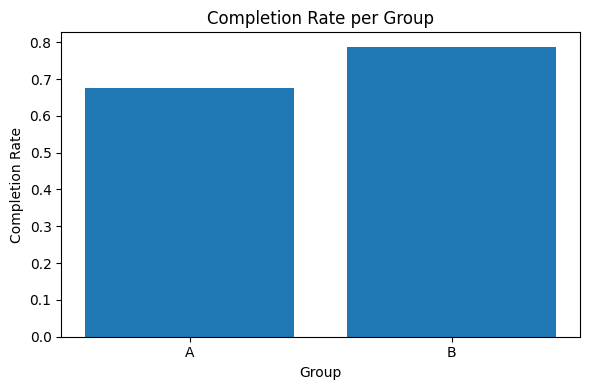

In [39]:
ab_summary = ab_test.groupby('group').agg(
    users=('group', 'count'),
    completion_rate=('completed_allocation', 'mean'),
    avg_saving_intention=('saving_intention_score', 'mean')
).reset_index()
display(ab_summary)

plt.figure(figsize=(6, 4))
plt.bar(ab_summary['group'], ab_summary['completion_rate'])
plt.title('Completion Rate per Group')
plt.xlabel('Group')
plt.ylabel('Completion Rate')
plt.tight_layout()
plt.show()

EXPORT AI

In [40]:
artifacts = {
    'rule_engine': engine,
    'persona_model': persona_model,
    'regressors': regressors,
    'cluster_to_persona': cluster_to_persona,
    'feature_cols': feature_cols,
    'regression_metrics': metrics_df.to_dict(orient='records'),
    'silhouette_score': float(sil)
}

joblib.dump(artifacts, ARTIFACT_DIR / 'smart_expense_ai_artifacts.pkl')

model_card = {
    'project': 'Smart Expense',
    'team_id': 'CC26-PSU402',
    'ai_scope': [
        'Rule-based allocation recommendation',
        'Smart suggestion generation',
        'Financial persona segmentation support',
        'Backend integration payload'
    ],
    'recommended_production_mode': 'rule_based_core_with_optional_ml_insight',
    'input': {'amount': 'Nominal uang/gaji pengguna', 'profile': 'hemat/seimbang/agresif_menabung'},
    'output': ['allocation', 'percentages', 'suggestions', 'persona'],
    'limitations': [
        'Dataset historis bersifat simulasi dan belum mewakili semua kondisi pengguna.',
        'Model ML hanya digunakan sebagai insight pendukung, bukan keputusan finansial mutlak.',
        'Rekomendasi perlu disertai disclaimer bahwa hasil bersifat edukatif.'
    ],
    'metrics': {
        'persona_silhouette_score': float(sil),
        'regression_mae': metrics_df.to_dict(orient='records')
    }
}

with open(ARTIFACT_DIR / 'model_card.json', 'w', encoding='utf-8') as f:
    json.dump(model_card, f, indent=2, ensure_ascii=False)

print('Artefak tersimpan di:', ARTIFACT_DIR)
print(list(ARTIFACT_DIR.iterdir()))

Artefak tersimpan di: /content/smart_expense_ai_artifacts
[PosixPath('/content/smart_expense_ai_artifacts/smart_expense_ai_artifacts.pkl'), PosixPath('/content/smart_expense_ai_artifacts/model_card.json')]


In [41]:
print("Columns:", monthly.columns.tolist())

dl_df = monthly.copy()

# NEEDS
if 'needs' not in dl_df.columns:
    if 'needs_amount' in dl_df.columns:
        dl_df['needs'] = dl_df['needs_amount']
    elif 'Needs' in dl_df.columns:
        dl_df['needs'] = dl_df['Needs']
    else:
        dl_df['needs'] = dl_df['income'] * 0.50

# WANTS
if 'wants' not in dl_df.columns:
    if 'wants_amount' in dl_df.columns:
        dl_df['wants'] = dl_df['wants_amount']
    elif 'Wants' in dl_df.columns:
        dl_df['wants'] = dl_df['Wants']
    else:
        dl_df['wants'] = dl_df['income'] * 0.30

# SAVINGS
if 'savings' not in dl_df.columns:
    if 'savings_amount' in dl_df.columns:
        dl_df['savings'] = dl_df['savings_amount']
    elif 'Savings' in dl_df.columns:
        dl_df['savings'] = dl_df['Savings']
    else:
        dl_df['savings'] = dl_df['income'] * 0.20


dl_df['needs_rate'] = dl_df['needs'] / dl_df['income']
dl_df['wants_rate'] = dl_df['wants'] / dl_df['income']
dl_df['saving_rate'] = dl_df['savings'] / dl_df['income']

dl_df = dl_df.replace([np.inf, -np.inf], np.nan)

dl_df = dl_df.dropna(subset=[
    'income',
    'needs_rate',
    'wants_rate',
    'saving_rate'
])


dl_df['expense_total'] = dl_df['needs'] + dl_df['wants']

dl_df['cashflow'] = (
    dl_df['income'] - dl_df['expense_total']
)

dl_df['expense_rate'] = np.where(
    dl_df['income'] > 0,
    dl_df['expense_total'] / dl_df['income'],
    0
)


dl_feature_cols = [
    'income',
    'expense_total',
    'cashflow',
    'expense_rate'
]

dl_target_cols = [
    'needs_rate',
    'wants_rate',
    'saving_rate'
]

X_dl = dl_df[dl_feature_cols].astype('float32').values
y_dl = dl_df[dl_target_cols].astype('float32').values

# Normalisasi target
y_dl = y_dl / np.clip(
    y_dl.sum(axis=1, keepdims=True),
    1e-8,
    None
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_dl,
    y_dl,
    test_size=0.2,
    random_state=42
)

dl_scaler = StandardScaler()

X_train_scaled = dl_scaler.fit_transform(
    X_train
).astype('float32')

X_test_scaled = dl_scaler.transform(
    X_test
).astype('float32')

print("Train shape:", X_train_scaled.shape, y_train.shape)
print("Test shape:", X_test_scaled.shape, y_test.shape)

Columns: ['month', 'income', 'kebutuhan_pokok', 'kebutuhan_sekunder', 'lainnya', 'tabungan', 'total_allocated', 'saving_rate', 'needs_rate', 'wants_rate']
Train shape: (45, 4) (45, 3)
Test shape: (12, 4) (12, 3)


In [42]:
!pip install groq

In [43]:
from groq import Groq

client = Groq(
    api_key="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"
)

chat_completion = client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": "Halo"
        }
    ],
    model="llama-3.3-70b-versatile"
)

print(chat_completion.choices[0].message.content)

Halo, how can I help you today?


In [44]:
from groq import Groq

client = Groq(
    api_key="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"
)

hasil_prediksi = """
Income: 5000000
Kebutuhan Pokok: 2500000
Tabungan: 1000000
Saving Rate: 20%
"""

prompt = f"""
Berikan analisis kondisi keuangan user berikut:

{hasil_prediksi}

Berikan saran keuangan yang singkat dan jelas.
"""

response = client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ],
    model="llama-3.3-70b-versatile"
)

print(response.choices[0].message.content)

Berdasarkan data yang diberikan, kita dapat melakukan analisis sebagai berikut:

1. Pendapatan bulanan: Rp 5.000.000
2. Kebutuhan pokok: Rp 2.500.000
3. Tabungan: Rp 1.000.000
4. Saving Rate: 20%

Dari data di atas, kita dapat menghitung pengeluaran yang tidak esensial sebagai berikut:
Pengeluaran total = Pendapatan - Kebutuhan pokok - Tabungan
Pengeluaran total = Rp 5.000.000 - Rp 2.500.000 - Rp 1.000.000 = Rp 1.500.000

Saving Rate yang diinginkan adalah 20% dari pendapatan, yaitu:
Saving Rate = 20% x Rp 5.000.000 = Rp 1.000.000

Karena sudah mencapai target Saving Rate, maka saran yang dapat diberikan adalah:
- Terus pertahankan Saving Rate yang baik dan cobalah untuk meningkatkan nilai tabungan dengan meningkatkan pendapatan atau mengurangi pengeluaran tidak esensial.
- Periksa pengeluaran tidak esensial dan pastikan bahwa pengeluaran tersebut sesuai dengan prioritas dan kebutuhan.
- Pertimbangkan untuk memiliki dana darurat yang cukup untuk menghadapi situasi darurat yang tidak te

In [47]:
!zip -r smart_expense_ai.zip smart_expense_ai_artifacts

  adding: smart_expense_ai_artifacts/ (stored 0%)
  adding: smart_expense_ai_artifacts/smart_expense_ai_artifacts.pkl (deflated 77%)
  adding: smart_expense_ai_artifacts/model_card.json (deflated 49%)


In [48]:
!zip -r smart_expense_tf.zip smart_expense_tf_artifacts

  adding: smart_expense_tf_artifacts/ (stored 0%)
  adding: smart_expense_tf_artifacts/smart_expense_dl_metadata.json (deflated 46%)
  adding: smart_expense_tf_artifacts/smart_expense_dl_scaler.joblib (deflated 31%)
  adding: smart_expense_tf_artifacts/smart_expense_allocation_model.keras (deflated 73%)
  adding: smart_expense_tf_artifacts/smart_expense_saved_model/ (stored 0%)
  adding: smart_expense_tf_artifacts/smart_expense_saved_model/assets/ (stored 0%)
  adding: smart_expense_tf_artifacts/smart_expense_saved_model/fingerprint.pb (stored 0%)
  adding: smart_expense_tf_artifacts/smart_expense_saved_model/saved_model.pb (deflated 84%)
  adding: smart_expense_tf_artifacts/smart_expense_saved_model/variables/ (stored 0%)
  adding: smart_expense_tf_artifacts/smart_expense_saved_model/variables/variables.index (deflated 60%)
  adding: smart_expense_tf_artifacts/smart_expense_saved_model/variables/variables.data-00000-of-00001 (deflated 55%)
